# Tutorial: additive and zero-sum sequences

This notebook is a small, executable introduction to `zero_sum_sequences`.  It deliberately stays with examples that can be checked by hand and works with any compatible additive Sage parent.

It can be run directly on Binder using the repository's `sagelite` environment.  The examples use ordinary Python syntax with Sage's established `sage.all` import namespace, so no Sage preparser is required.  Every assertion below is intended to pass from a fresh kernel.

## 1. Configure a sequence space

An `AdditiveSequenceSpace` fixes two pieces of data once: an additive Sage parent and an upper bound for its Davenport constant.  Calling the space constructs immutable finite multisets of elements of that parent.  The package never tries to inspect the parent for this bound, so a bound that is too small can omit atoms and make factorization results incomplete.

For the cyclic group $C_3=\mathbb Z/3\mathbb Z$, the Davenport constant is 3.

In [1]:
from sage.all import Zmod

from zero_sum_sequences import (
    AdditiveSequenceSpace,
    AtomCatalogue,
    FactorizationSolver,
)

C3 = AdditiveSequenceSpace(Zmod(3), davenport_bound=3)
print('base parent:', C3.base_parent)
print('Davenport bound:', C3.davenport_bound)

base parent: Ring of integers modulo 3
Davenport bound: 3


## 2. Construct and inspect sequences

The constructor coerces terms through the configured Sage parent and stores a canonical multiplicity table.  Thus the order used to construct a sequence is irrelevant.  A sequence is *zero-sum* when the sum of all its terms is zero, and it is an *atom* when it is a nonempty zero-sum sequence without a proper nonempty zero-sum subsequence.

In [2]:
sample = C3([2, 1, 2, 1])

print('sequence:', sample)
print('parent is C3:', sample.parent() is C3)
print('terms:', tuple(sample))
print('length:', len(sample))
print('support:', sample.support)
print('multiplicities:', sample.multiplicities)
print('total:', sample.total())
print('zero-sum:', sample.is_zero_sum())
print('atom:', sample.is_atom())

assert tuple(sample) == (C3.base_parent(1), C3.base_parent(1), C3.base_parent(2), C3.base_parent(2))
assert len(sample) == 4
assert sample.total() == C3.base_parent.zero()
assert sample.is_zero_sum()
assert not sample.is_atom()  # 1 · 2 is already a zero-sum subsequence

sequence: (1)^2 · (2)^2
parent is C3: True
terms: (1, 1, 2, 2)
length: 4
support: (1, 2)
multiplicities: {1: 2, 2: 2}
total: 0
zero-sum: True
atom: False


## 3. Multiset arithmetic

Addition combines multiplicities, subtraction removes a subsequence, and multiplication by a nonnegative integer repeats a sequence.  `divides` tests the multiset-subsequence relation.  All of these operations keep the same configured sequence space.

In [3]:
pair = C3([1, 2])
triple_pair = 3 * pair

print('pair:', pair)
print('pair + pair:', pair + pair)
print('sample - pair:', sample - pair)
print('3 * pair:', triple_pair)
print('pair divides sample:', pair.divides(sample))

assert pair + pair == sample
assert sample - pair == pair
assert triple_pair == C3([1, 1, 1, 2, 2, 2])
assert pair.divides(sample)
assert not triple_pair.divides(sample)

pair: 1 · 2
pair + pair: (1)^2 · (2)^2
sample - pair: 1 · 2
3 * pair: (1)^3 · (2)^3
pair divides sample: True


## 4. Factorizations and length sets

Consider $S=1^3 2^3$ over $C_3$.  It has two visible factorizations into atoms:

$$S=(1^3)(2^3)=(1\cdot2)^3.$$

Their lengths are 2 and 3.  `length_set()` computes the complete set, while `factorization_witnesses()` keeps one deterministic witness for each length.

In [4]:
sequence = C3([1, 1, 1, 2, 2, 2])
one_cubed = C3([1, 1, 1])
two_cubed = C3([2, 2, 2])
mixed_pair = C3([1, 2])

assert all(atom.is_atom() for atom in (one_cubed, two_cubed, mixed_pair))
assert one_cubed + two_cubed == sequence
assert 3 * mixed_pair == sequence

lengths = sequence.length_set()
witnesses = sequence.factorization_witnesses()

def format_factorization(factors):
    return '  *  '.join(str(factor) for factor in factors) or '1'

print('length set:', sorted(lengths))
for length, factors in witnesses.items():
    print(f'length {length}: {format_factorization(factors)}')

assert lengths == {2, 3}
assert witnesses == sequence.factorization_witnesses()
assert {len(factors) for factors in witnesses.values()} == {2, 3}
assert all(sum(factors, C3()) == sequence for factors in witnesses.values())

length set: [2, 3]
length 2: (1)^3  *  (2)^3
length 3: 1 · 2  *  1 · 2  *  1 · 2


`factorizations()` enumerates every unordered factorization exactly once.  Enumeration is output-sensitive, so for large examples the length set or one witness per length is usually the more useful query.  Here the complete list is short enough to inspect directly.

In [5]:
all_factorizations = sorted(sequence.factorizations(), key=len)
for factors in all_factorizations:
    print(f'length {len(factors)}: {format_factorization(factors)}')

assert len(all_factorizations) == 2
assert {len(factors) for factors in all_factorizations} == {2, 3}
assert all(sum(factors, C3()) == sequence for factors in all_factorizations)

length 2: (1)^3  *  (2)^3
length 3: 1 · 2  *  1 · 2  *  1 · 2


## 5. Advanced: reuse a factorization solver

The sequence methods are the ordinary interface.  When several queries will use the same input, `FactorizationSolver` exposes the memoized remainder DAG directly, so the discovered atoms and states are reused.  Its statistics report the number of relevant atom divisors, remainder states, and transitions.

In [6]:
solver = FactorizationSolver(sequence)
assert solver.length_set() == lengths
assert solver.factorization_witnesses() == witnesses

stats = solver.statistics
print('candidate atoms:', stats.candidate_atoms)
print('remainder states:', stats.states)
print('transitions:', stats.transitions)

assert (stats.candidate_atoms, stats.states, stats.transitions) == (3, 5, 5)

candidate atoms: 3
remainder states: 5
transitions: 5


## 6. Inspect the factorization DAG

`sequence.factorization_digraph()` returns the memoized directed acyclic graph.  Its vertices are remainder sequences; an edge removes the atom carried by its label.  A path from the input sequence to the empty sequence therefore encodes a factorization.

In [7]:
dag = sequence.factorization_digraph()
edges = sorted(
    (str(source), str(target), str(atom))
    for source, target, atom in dag.edge_iterator(labels=True)
)

print(f'vertices: {dag.num_verts()}; edges: {dag.num_edges()}')
for source, target, atom in edges:
    print(f'{source}  -- remove {atom} -->  {target}')

assert dag.is_directed() and dag.is_directed_acyclic()
assert sequence in dag and C3() in dag
assert {len(path) - 1 for path in dag.all_paths(sequence, C3())} == lengths
assert all(source - atom == target for source, target, atom in dag.edge_iterator(labels=True))

vertices: 5; edges: 5
(1)^2 · (2)^2  -- remove 1 · 2 -->  1 · 2
(1)^3 · (2)^3  -- remove 1 · 2 -->  (1)^2 · (2)^2
(1)^3 · (2)^3  -- remove (1)^3 -->  (2)^3
(2)^3  -- remove (2)^3 -->  1
1 · 2  -- remove 1 · 2 -->  1


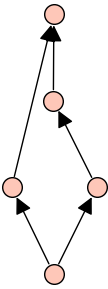

In [8]:
# A compact, headless-safe Sage plot.  It is an ordinary notebook output,
# not a GUI call.
dag.plot(vertex_labels=False, edge_labels=False, layout='acyclic', figsize=4)

## 7. Reuse a complete atom catalogue

For this particular input, the complete list of atom divisors is $1^3$, $2^3$, and $1\cdot2$.  `AtomCatalogue` can index a precomputed collection and avoid rediscovering those atoms.  **Completeness is the caller's responsibility:** for complete factorization results, the catalogue must contain every atom divisor relevant to the sequence.

In [9]:
relevant_atoms = (one_cubed, two_cubed, mixed_pair)
catalogue = AtomCatalogue(C3, relevant_atoms)
catalogue_divisors = tuple(catalogue.divisors(sequence))

print('catalogue atoms:', [str(atom) for atom in catalogue])
print('divisors of S:', [str(atom) for atom in catalogue_divisors])

assert set(catalogue_divisors) == set(relevant_atoms)
assert sequence.length_set(atom_catalogue=catalogue) == lengths
assert sequence.factorization_witnesses(atom_catalogue=catalogue) == witnesses
assert FactorizationSolver(sequence, atom_catalogue=catalogue).statistics == stats

catalogue atoms: ['1 · 2', '(1)^3', '(2)^3']
divisors of S: ['1 · 2', '(1)^3', '(2)^3']


## Next steps

The [README](../README.md) summarizes installation, the public API, and the benchmark suite.